# Load all datasets

In [26]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
room_conditions = pd.read_csv('../data/raw/room_conditions.csv')
room_conditions.head()


,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,23.7000,26.272,585.200000,749.200000,0.004764,1
1,23.7180,26.290,578.400000,760.400000,0.004773,1
2,23.7300,26.230,572.666667,769.666667,0.004765,1
3,23.7225,26.125,493.750000,774.750000,0.004744,1
4,23.7540,26.200,488.600000,779.000000,0.004767,1


In [28]:
data = room_conditions.copy()

# drop occupancy column
data = data.drop('Occupancy', axis=1)

# drop humidity ratio column
data = data.drop('HumidityRatio', axis=1)

data.head()

,Temperature,Humidity,Light,CO2
0,23.7000,26.272,585.200000,749.200000
1,23.7180,26.290,578.400000,760.400000
2,23.7300,26.230,572.666667,769.666667
3,23.7225,26.125,493.750000,774.750000
4,23.7540,26.200,488.600000,779.000000


In [29]:
# Shape of data
print(f'Shape of data: {data.shape}')

Shape of data: (2665, 4)


Now the time difference between the measurements has to be taken into account to be able to calculate features like temp_max_30min, and similar. 
Because the dataset does not disclose the exact time of the measurements, it will be roughly calculated based on the rate of change of individual variables.

In [30]:
# Analyse any suspicious jumps of values between measurements
data_diff = data.diff().abs()
data_diff.describe()

,Temperature,Humidity,Light,CO2
count,2664.000000,2664.000000,2664.000000,2664.000000
mean,0.014224,0.032614,3.421995,3.802458
std,0.020607,0.044862,25.455092,3.715309
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,1.250000
50%,0.000000,0.022500,0.000000,2.833333
75%,0.025000,0.050000,1.000000,5.166667
max,0.110000,0.993000,652.500000,51.050000


Out of the features temp, humidity, light, co2, some of them can't change too much in a short time. "Too much" in objective terms can be described as a deviation from the mean difference between consecutive measurements. Let's just quickly see how it would look if we plot the number of sessions depending on how strict we are at what we consider an outlier in the rate of change.

Total rows: 2665
Multiplier std: 1.0, Number of sessions: 824
Multiplier std: 1.2, Number of sessions: 697
Multiplier std: 1.4, Number of sessions: 579
Multiplier std: 1.6, Number of sessions: 474
Multiplier std: 1.8, Number of sessions: 368
Multiplier std: 2.0, Number of sessions: 285
Multiplier std: 2.2, Number of sessions: 255
Multiplier std: 2.4, Number of sessions: 214
Multiplier std: 2.6, Number of sessions: 165
Multiplier std: 2.8, Number of sessions: 140
Multiplier std: 3.0, Number of sessions: 91
Multiplier std: 3.2, Number of sessions: 78
Multiplier std: 3.4, Number of sessions: 66
Multiplier std: 3.6, Number of sessions: 61
Multiplier std: 3.8, Number of sessions: 49
Multiplier std: 4.0, Number of sessions: 44
Multiplier std: 4.2, Number of sessions: 30
Multiplier std: 4.4, Number of sessions: 29
Multiplier std: 4.6, Number of sessions: 25
Multiplier std: 4.8, Number of sessions: 22
Multiplier std: 5.0, Number of sessions: 21
Multiplier std: 5.2, Number of sessions: 17
Multi

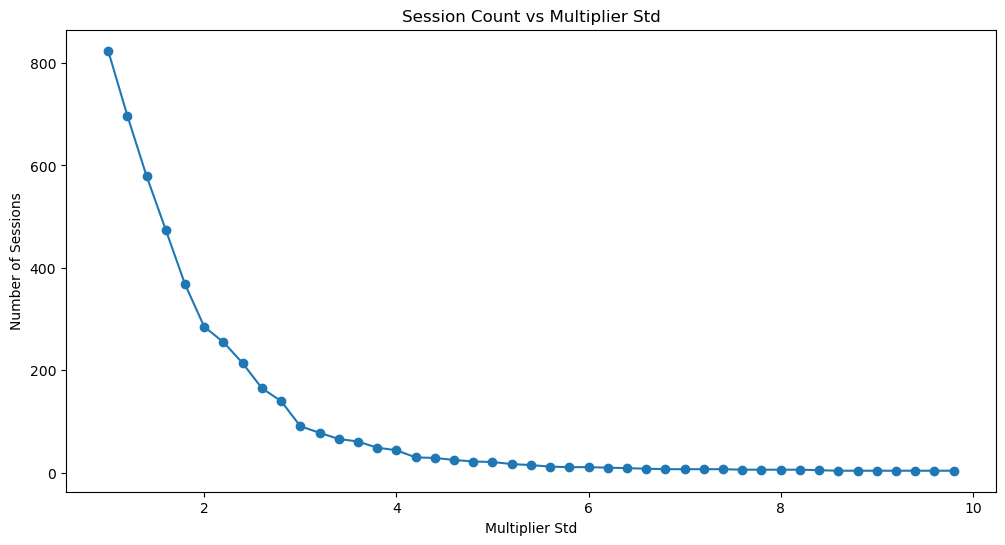

In [31]:
# Split data into sessions based on jumps in values for temp, humidity, and CO2 (light can change)

SESSION_SPLIT_COLUMNS = ['Temperature', 'Humidity', 'CO2']


def get_jump_thresholds(data_diff, multiplier_std, columns=SESSION_SPLIT_COLUMNS):
    return data_diff[columns].mean() + multiplier_std * data_diff[columns].std()


def split_sessions(data_diff, multiplier_std, columns=SESSION_SPLIT_COLUMNS):
    jump_thresholds = get_jump_thresholds(data_diff, multiplier_std, columns)
    session_starts = data_diff[columns].gt(jump_thresholds).any(axis=1)
    return session_starts.cumsum()


multiplier_std = 6
sessions = split_sessions(data_diff, multiplier_std)

# Explore integer and non-integer multiplier_std values to see how many sessions they yield
print(f"Total rows: {data.shape[0]}")
multiplier_stds = np.arange(1.0, 10, 0.2)
session_counts = pd.Series(
    {multiplier_std: split_sessions(data_diff, multiplier_std).nunique() for multiplier_std in multiplier_stds},
    name='session_count',
)

for multiplier_std, session_count in session_counts.items():
    print(f'Multiplier std: {multiplier_std:.1f}, Number of sessions: {session_count}')
    
# Visualize session count vs multiplier_std

plt.figure(figsize=(12, 6))
plt.plot(session_counts.index, session_counts.values, marker='o')
plt.xlabel('Multiplier Std')
plt.ylabel('Number of Sessions')
plt.title('Session Count vs Multiplier Std')
plt.show()

Let's get back at seeing the mean change per unit of time for variables like temp, humidity, light, co2. This will be the basis for the session splitting. There must be some threshold that categorizes as generally acceptable or not. Light is not taken into account because that can change immediately and drastically, and it is not a good indicator of the time difference between measurements. (we could also see this before)

So if we know what is the usual change of temp, ... per some unit of time (let's say per minute), we can look at our data and figure out what the unit of time in our data is. The problem would still be not knowing the size of the room but some error is expected. 

Per minute, usual change is:
- temp: 0.1 (high variability)
- humidity: 0.5-2.0 (https://wufi.de/literatur/K%C3%BCnzel%20-%20Indoor%20Relative%20Humidity%20in%20Residential.pdf)
- co2: 15-20 (no reliable source confirming)

With these values and our results of mean change:
temp | humidity | light | co2
0.014224 | 0.032614 | 3.421995 | 3.802458

It can be estimated that the time difference between measurements is from 5 to 10 minutes. 

TODO: find max thresholds for temp, humidity, co2 and split the sessions based on that, assuming time difference of 5-10 minutes. Then we split based on sessions and only then we can crunch to mock target, once we compress rectangular to linear.

# Mocking Target

The plan is to create a deterministic function that asses the room conditions based on some personality profile and then outputs the rating of the current conditions of the room on a scale. Then random noise is added to this and in general this gives the target variable for the model to predict. 